# 05 - Advanced Mutual Fund Analytics
**Bluestock Mutual Fund Analytics Capstone Project**

This notebook uses the existing Day 1-4 datasets and the Phase 2 recommendation engine.

## Setup - Imports and Data Loading

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from recommender import recommend

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 80)

scorecard = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "fund_scorecard.csv")
performance = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "performance_clean.csv")
aum = pd.read_csv(
    PROJECT_ROOT / "data" / "raw" / "03_aum_by_fund_house.csv",
    parse_dates=["date"],
)

scorecard = scorecard.sort_values("fund_score_100", ascending=False).reset_index(drop=True)
print(f"Scorecard: {scorecard.shape[0]} funds")
print(f"Performance data: {performance.shape[0]} funds")
print(f"AUM history: {aum.shape[0]} rows through {aum['date'].max().date()}")

Scorecard: 40 funds
Performance data: 40 funds
AUM history: 90 rows through 2025-12-31


---
## SECTION 1 - Top 10 Funds

The scorecard is ordered with the highest fund score first. The requested `scorecard.head(10)` view shows fund name, fund score, Sharpe ratio, and three-year return.

In [2]:
top_10_funds = scorecard.head(10)[
    ["scheme_name", "fund_score_100", "sharpe_ratio", "return_3yr_pct"]
].copy()
top_10_funds.columns = ["Fund Name", "Fund Score", "Sharpe Ratio", "Return (%)"]
top_10_funds.index = range(1, len(top_10_funds) + 1)
top_10_funds.index.name = "Rank"
top_10_funds.round({"Fund Score": 2, "Sharpe Ratio": 3, "Return (%)": 2})

,Fund Name,Fund Score,Sharpe Ratio,Return (%)
Rank,,,,
1,SBI Small Cap Fund - Direct Plan - Growth,100.00,0.93,23.14
2,Kotak Flexicap Fund - Regular - Growth,97.42,0.98,15.65
3,Kotak Emerging Equity Fund - Regular - Growth,95.36,0.96,18.23
4,ABSL Small Cap Fund - Regular - Growth,90.72,0.90,22.38
5,SBI Small Cap Fund - Regular Plan - Growth,82.73,0.94,23.39
6,Mirae Asset Large Cap Fund - Regular - Growth,81.83,1.06,14.81
7,HDFC Short Term Debt Fund - Regular - Growth,79.90,1.84,7.37
8,ICICI Pru Liquid Fund - Regular - Growth,77.32,7.68,7.68
9,ICICI Pru Midcap Fund - Regular - Growth,75.77,0.95,18.08


**Interpretation:** These funds lead the combined Day 4 scorecard. The ordering prioritizes the composite fund score; Sharpe ratio and return provide additional performance context.

---
## SECTION 2 - Best Fund House

Because the AUM dataset contains multiple reporting dates, the latest snapshot is selected before applying `aum.groupby("fund_house")`. This avoids adding the same assets repeatedly across time.

In [3]:
latest_aum_date = aum["date"].max()
latest_aum = aum.loc[aum["date"].eq(latest_aum_date)].copy()

fund_house_ranking = (
    latest_aum.groupby("fund_house", as_index=False)
    .agg(total_aum_crore=("aum_crore", "sum"))
    .sort_values("total_aum_crore", ascending=False)
    .reset_index(drop=True)
)
fund_house_ranking.insert(0, "ranking", range(1, len(fund_house_ranking) + 1))
fund_house_ranking.columns = ["Ranking", "Fund House", "Total AUM (Crore)"]

print(f"Latest AUM snapshot: {latest_aum_date.date()}")
fund_house_ranking

Latest AUM snapshot: 2025-12-31


,Ranking,Fund House,Total AUM (Crore)
0,1,SBI Mutual Fund,1250000
1,2,ICICI Prudential MF,1074000
2,3,HDFC Mutual Fund,930000
3,4,Nippon India MF,700000
4,5,Kotak Mahindra MF,580000
5,6,Aditya Birla Sun Life MF,460000
6,7,UTI Mutual Fund,410000
7,8,Axis Mutual Fund,350000
8,9,Mirae Asset MF,290000
9,10,DSP Mutual Fund,230000


**Interpretation:** The first-ranked fund house manages the highest total AUM in the latest available project snapshot. AUM indicates scale, not necessarily superior risk-adjusted performance.

---
## SECTION 3 - Risk vs Return Analysis

Risk is represented by annualized standard deviation (`std_dev_ann_pct`), while return is the three-year percentage return (`return_3yr_pct`).

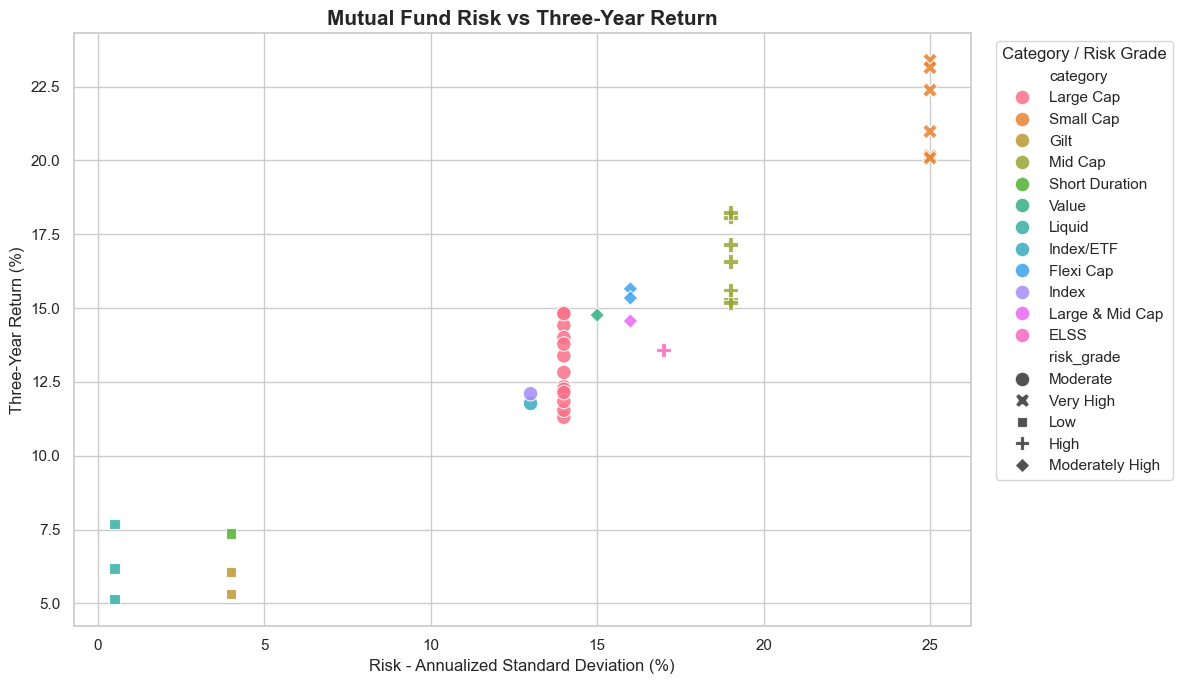

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=performance,
    x="std_dev_ann_pct",
    y="return_3yr_pct",
    hue="category",
    style="risk_grade",
    s=110,
    alpha=0.85,
    ax=ax,
)
ax.set_title("Mutual Fund Risk vs Three-Year Return", fontsize=15, weight="bold")
ax.set_xlabel("Risk - Annualized Standard Deviation (%)")
ax.set_ylabel("Three-Year Return (%)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Category / Risk Grade")
fig.tight_layout()
plt.show()

**Interpretation:** Funds farther right have greater annualized volatility, while funds higher on the chart have stronger three-year returns. The most attractive risk-return region is generally the upper-left, where returns are higher for comparatively lower risk. Category and risk-grade markers show that higher-return equity categories typically carry more volatility than liquid and debt-oriented funds.

---
## SECTION 4 - Fund Recommendation Engine Demo

The Phase 2 engine filters funds by risk profile and ranks eligible funds by fund score, Sharpe ratio, and three-year return.

In [5]:
low_risk_recommendations = recommend("Low")
low_risk_recommendations

,recommendation_rank,amfi_code,scheme_name,fund_house,category,plan,risk_grade,risk_score,fund_score_100,sharpe_ratio,return_3yr_pct
0,1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,Low,1,79.8969,1.84,7.37
1,2,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,Low,1,77.3196,7.68,7.68
2,3,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,Low,1,66.2371,6.18,6.18
3,4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,Low,1,55.6701,1.52,6.07
4,5,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,Low,1,46.3918,5.14,5.14


**Low risk:** Only funds with risk score 2 or below are eligible, emphasizing capital stability and lower-volatility categories.

In [6]:
medium_risk_recommendations = recommend("Medium")
medium_risk_recommendations

,recommendation_rank,amfi_code,scheme_name,fund_house,category,plan,risk_grade,risk_score,fund_score_100,sharpe_ratio,return_3yr_pct
0,1,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,Moderately High,4,97.4227,0.98,15.65
1,2,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,Moderate,3,81.8299,1.06,14.81
2,3,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,Low,1,79.8969,1.84,7.37
3,4,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,Low,1,77.3196,7.68,7.68
4,5,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,Moderate,3,72.9381,1.03,14.41


**Medium risk:** Funds with risk score 4 or below are eligible, widening the selection to moderate and moderately high risk funds while retaining lower-risk candidates.

In [7]:
high_risk_recommendations = recommend("High")
high_risk_recommendations

,recommendation_rank,amfi_code,scheme_name,fund_house,category,plan,risk_grade,risk_score,fund_score_100,sharpe_ratio,return_3yr_pct
0,1,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,Very High,6,100.0000,0.93,23.14
1,2,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,Moderately High,4,97.4227,0.98,15.65
2,3,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,High,5,95.3608,0.96,18.23
3,4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,Very High,6,90.7216,0.90,22.38
4,5,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,Very High,6,82.7320,0.94,23.39


**High risk:** All funds are eligible, allowing higher-risk equity and small-cap funds to compete directly on score, Sharpe ratio, and return.

---
## PHASE 4 - Portfolio Optimization

The five highest-ranked scorecard funds are allocated in proportion to their Sharpe ratios:

$$\text{Weight}_i = \frac{\text{Sharpe Ratio}_i}{\sum_{j=1}^{5}\text{Sharpe Ratio}_j}$$

In [8]:
portfolio = scorecard.head(5)[
    ["scheme_name", "fund_score_100", "sharpe_ratio", "return_3yr_pct"]
].copy()

if portfolio["sharpe_ratio"].isna().any():
    raise ValueError("Top five funds contain missing Sharpe ratios.")
if portfolio["sharpe_ratio"].le(0).any():
    raise ValueError("Sharpe-proportional allocation requires positive Sharpe ratios.")

sharpe_total = portfolio["sharpe_ratio"].sum()
portfolio["allocation_pct"] = (
    portfolio["sharpe_ratio"].div(sharpe_total).mul(100).round(4)
)

allocation_table = portfolio.rename(
    columns={
        "scheme_name": "Fund Name",
        "fund_score_100": "Fund Score",
        "sharpe_ratio": "Sharpe Ratio",
        "return_3yr_pct": "Return (%)",
        "allocation_pct": "Suggested Allocation (%)",
    }
).reset_index(drop=True)
allocation_table.index = range(1, len(allocation_table) + 1)
allocation_table.index.name = "Portfolio Rank"

print(f"Total portfolio allocation: {allocation_table['Suggested Allocation (%)'].sum():.4f}%")
allocation_table

Total portfolio allocation: 100.0000%


,Fund Name,Fund Score,Sharpe Ratio,Return (%),Suggested Allocation (%)
Portfolio Rank,,,,,
1,SBI Small Cap Fund - Direct Plan - Growth,100.0000,0.93,23.14,19.7452
2,Kotak Flexicap Fund - Regular - Growth,97.4227,0.98,15.65,20.8068
3,Kotak Emerging Equity Fund - Regular - Growth,95.3608,0.96,18.23,20.3822
4,ABSL Small Cap Fund - Regular - Growth,90.7216,0.90,22.38,19.1083
5,SBI Small Cap Fund - Regular Plan - Growth,82.7320,0.94,23.39,19.9575


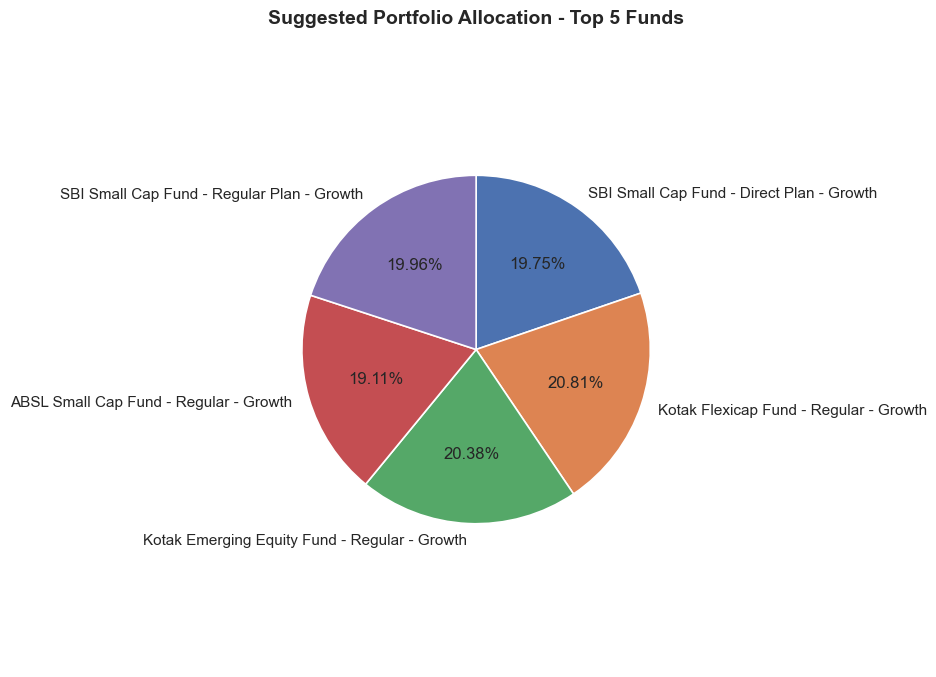

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.pie(
    allocation_table["Suggested Allocation (%)"],
    labels=allocation_table["Fund Name"],
    autopct="%1.2f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white", "linewidth": 1.2},
)
ax.set_title("Suggested Portfolio Allocation - Top 5 Funds", fontsize=14, weight="bold")
ax.axis("equal")
fig.tight_layout()
plt.show()

**Interpretation:** A fund receives a larger allocation when its Sharpe ratio contributes more to the combined Sharpe ratio of the selected portfolio. This transparent heuristic favors stronger historical risk-adjusted performance, but it does not account for correlations between funds, concentration limits, taxes, or investor-specific constraints.

---
## Notebook Validation

In [10]:
assert len(top_10_funds) == 10
assert fund_house_ranking["Ranking"].iloc[0] == 1
assert len(low_risk_recommendations) == 5
assert len(medium_risk_recommendations) == 5
assert len(high_risk_recommendations) == 5
assert low_risk_recommendations["risk_score"].le(2).all()
assert medium_risk_recommendations["risk_score"].le(4).all()
assert len(allocation_table) == 5
assert allocation_table["Suggested Allocation (%)"].ge(0).all()
assert abs(allocation_table["Suggested Allocation (%)"].sum() - 100.0) < 1e-9

print("[PASS] SECTION 1 - Top 10 funds")
print("[PASS] SECTION 2 - Fund-house AUM ranking")
print("[PASS] SECTION 3 - Risk vs return chart")
print("[PASS] SECTION 4 - Low, Medium, and High recommendations")
print("[PASS] PHASE 4 - Portfolio weights total 100%")
print("Notebook validation completed successfully.")

[PASS] SECTION 1 - Top 10 funds
[PASS] SECTION 2 - Fund-house AUM ranking
[PASS] SECTION 3 - Risk vs return chart
[PASS] SECTION 4 - Low, Medium, and High recommendations
[PASS] PHASE 4 - Portfolio weights total 100%
Notebook validation completed successfully.
